In [4]:
import pandas as pd
import numpy as np
from pandas_datareader.data import DataReader
import matplotlib.pyplot as plt
import yfinance as yf
import seaborn as sns
import math 

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Two-State Interacting Agent-Based Model

In 2000, **<span style="color: #2e6f40;">Taisei Kaizoji</span>**([see reference](https://www.sciencedirect.com/science/article/abs/pii/S0378437100003885?via%3Dihub)) proposed a pioneering agent-based model to describe financial market dynamics, focusing specifically on the formation and collapse of speculative bubbles and market crashes. 

The core philosophy of this model is to analyze markets through the lens of **mass psychology** rather than fundamental values. Under this framework, investors do not seek to estimate the intrinsic value of an asset. Instead, they try to anticipate how the crowd of other investors will behave in the near future. 

This mechanism directly operationalizes John Maynard Keynes' famous ***<span style="color: #1f77b4;">beauty contest</span>*** paradox:

> "It is not a case of choosing those [faces] which, to the best of one's judgment, are really the prettiest, nor even those which average opinion genuinely thinks the prettiest. We have reached the third degree where we devote our intelligences to anticipating what average opinion expects the average opinion to be."
> — *J.M. Keynes, The General Theory (1936)*

---

### Model Specification

To model this collective behavior, we consider a market populated by $N$ heterogeneous traders, indexed from $0$ to $N-1$. At any given time, each trader $i$ adopts one of two potential investment attitudes:

$$x_i \in \{-1, 1\}$$

* $x_i = 1$ represents a **bullish** (buying) attitude.
* $x_i = -1$ represents a **bearish** (selling) attitude.

---

### The Disagreement Function</span>

Every trader aims to minimize their individual ***<span style="color: #d62728;">disagreement function</span>*** (or local energy state) $e_i$, which represents the psychological tension or misalignment of agent $i$ with respect to their peers and the global environment:

$$e_i(x) = -\frac{1}{2} \sum_{j=0}^{N-1} a_{ij} x_i x_j - b_i s x_i$$

Where:
* $a_{ij}$ represents the **interaction strength** (or coupling coefficient) between trader $i$ and trader $j$, modeling peer-to-peer influence and herd behavior.
* $b_i$ denotes the strength of the reaction of trader i upon the change of the investment environment $s$ 
* $x_i x_j$ captures the alignment of choices: if $a_{ij} > 0$, the agent experiences less tension (lower $e_i$) by aligning their action with their neighbors ($x_i = x_j$).


The ***<span style="color: #d627c4;">collective disagreement function</span>*** is then given by

$$ E(x) = -\frac{1}{2} \sum_{i=0}^{N-1} \sum_{j=0}^{N-1} a_{ij} x_i x_j - \sum_{i=0}^{N-1} b_i s x_i$$

### Probabilistic Framework and Statistical Mechanics

Now, let us assume that the decision-making process of traders is subject to a probabilistic rule. 

As the number of traders $N$ grows, calculating the exact state of the market becomes computationally explosive. Since each agent has two possible states, the system has $2^N$ possible configurations of investment attitudes.

For a large-scale market, analyzing every individual configuration directly is intractable. Therefore, we transition to a statistical mechanics framework. 

Let us define a random variable representing the market's state configuration:

$$\mathbf{x}^k = (x_1^k, x_2^k, \dots, x_N^k) \quad \text{for } k = 1, 2, \dots, K$$

where $K = 2^N$. Each specific configuration $\mathbf{x}^k$ occurs with a probability $P(\mathbf{x}^k)$, satisfying:

$$0 < P(\mathbf{x}^k) < 1 \quad \text{and} \quad \sum_{k=1}^{K} P(\mathbf{x}^k) = 1$$

---

### The Constrained Optimization Problem

Under this probabilistic formulation, the deterministic minimization of individual disagreement is replaced by a global constrained optimization problem. The market seeks to minimize the **expected global disagreement** (or average system energy) $\langle E(\mathbf{x}) \rangle$:

$$\min \langle E(\mathbf{x}) \rangle = \sum_{k=1}^{K} P(\mathbf{x}^k) E(\mathbf{x}^k)$$

Subject to a constant level of global uncertainty, measured by the **Shannon information entropy** $H$:

$$H = -\sum_{k=1}^{K} P(\mathbf{x}^k) \ln P(\mathbf{x}^k) = \text{constant}$$

And the probability normalization constraint:

$$\sum_{k=1}^{K} P(\mathbf{x}^k) = 1$$

where the global disagreement of configuration $\mathbf{x}^k$ is the average of all individual disagreement functions:

$$E(\mathbf{x}^k) = \frac{1}{2} \sum_{i=1}^{N} e_i(\mathbf{x}^k)$$

---

### The Boltzmann Solution & Market Temperature

Using the method of Lagrange multipliers, the analytical solution to this optimization problem yields the well-known **Boltzmann distribution**:

$$P(\mathbf{x}^k) = \frac{1}{Z} \exp\left(-\mu E(\mathbf{x}^k)\right)$$

Where $Z$ is the **partition function** that normalizes the probabilities over all possible configurations:

$$Z = \sum_{k=1}^{K} \exp\left(-\mu E(\mathbf{x}^k)\right)$$

In this financial physics context, we interpret the parameters as follows:

***$\mu$ (Intensity of Choice)***: This parameter represents the inverse of the **<span style="color: #1f77b4;">market temperature</span>** ($T = 1/\mu$). It quantifies the degree of rationality or noise in the market:
  * When $\mu \to \infty$ (zero market temperature), traders are perfectly rational and deterministically choose the state that minimizes disagreement.
  * When $\mu \to 0$ (infinite market temperature), trader behavior becomes completely random, dominated by noise.
* **<span style="color: #2e6f40;">Relative Expectation Formation</span>**: This optimization process—where traders dynamically balance their individual desire to minimize disagreement against the ambient noise and uncertainty of the crowd—is termed **relative expectation formation**.



### Links beetween price and investment attitudes

The trading volume in this market directly depends on the collective investment attitudes of all traders. 

We assume that each trader buys or sells a fixed quantity $q$ of the stock in any given period $t$. Under this assumption, the aggregate excess demand for the stock is proportional to the sum of all individual investment attitudes:

$$\text{Excess Demand}_t = q \sum_{i=1}^{N} x_{it}$$

To clear transactions, we assume the existence of a **market-maker** whose role is to adjust the asset price based on this imbalance:
* If excess demand is **positive** (more buyers than sellers), the market-maker **raises** the price.
* If excess demand is **negative** (more sellers than buyers), the market-maker **lowers** the price.

Mathematically, this price adjustment process is governed by:

$$\Delta y_{t+1} = y_{t+1} - y_t = \lambda q \sum_{i=1}^{N} x_{it}$$

Where:
* $y_t$ represents the log-price of the stock at period $t$.
* $\lambda > 0$</span> represents the **price adjustment speed** (market liquidity parameter).
* At **market equilibrium**, the market clears perfectly, meaning there is an equal number of buyers and sellers:

$$\sum_{i=1}^{N} x_{it} = 0$$


---

### 2.4 Mean-Field Approximation

To solve this system analytically without simulating all $2^N$ configurations, we use a **mean-field approximation**, a classical technique in statistical mechanics. 

Instead of tracking every individual connection $a_{ij}$, we assume that every agent interacts with the "average" state of the entire crowd. We define the **mean-field variable** $\langle x \rangle$ as the average investment attitude of the market:

$$\langle x \rangle = \left\langle \frac{1}{N} \sum_{i=1}^{N} x_i \right\rangle \in [-1, 1]$$

To simplify the network, we assume uniform parameters across all agents:
* $a_{ij} = a$ (homogenous pairwise interaction strength).
* $b_i = b$ (homogenous environmental field).

This simplifies our interacting-agent model into a **Long-Range Ising Model** (where every agent is connected to every other agent with equal strength). The global disagreement function is approximated as:

$$E(\mathbf{x}) \approx -\frac{1}{2} a N \langle x \rangle \sum_{i=1}^{N} x_i - b \sum_{i=1}^{N} x_i$$

Because the partition function $Z$ relates to the average energy via the thermodynamic identity $\langle E(\mathbf{x}) \rangle = -\frac{\partial \ln Z}{\partial \mu}$, we can self-consistently solve for the average market attitude $\langle x \rangle$. This yields the famous **transcendental mean-field equation**:

$$\langle x \rangle = \tanh\left(\mu a N \langle x \rangle + \mu b\right)$$

This elegant equation mathematically represents ***<span style="color: #1f77b4;">Keynes' Beauty Contest</span>***: an agent's optimal decision $\langle x \rangle$ is a non-linear function ($\tanh$) of both the external fundamental news ($\mu b$) and their expectation of the average opinion of the crowd ($\mu a N \langle x \rangle$).

### Synchronous Dynamics and Trend Chasing

To study how the market evolves over time, we assume that the traders' investment attitudes change simultaneously (**synchronous dynamics**) in discrete time steps. We can represent these dynamics by iterating the mean-field equation:

$$\langle x \rangle_{t+1} = \tanh\left(\alpha \langle x \rangle_t + \beta s_t\right)$$

Where:
***$\alpha = \mu a N$*** is the ***<span style="color: #2e6f40;">bandwagon coefficient</span>***, which measures the strength with which traders chase the prevailing price trend (herd behavior).
***$\beta = \mu b$*** is the ***<span style="color: #d62728;">investment environment coefficient</span>***, which represents how strongly traders respond to external fundamental news $s_t$ at time $t$.


### Model Estimation: The Gradient-Descent Algorithm

Because the actual mean-field investment attitude $\langle x \rangle_t$ of all traders is a latent (unobservable) variable in empirical data, we use the **normalized stock price change** $\langle \Delta y \rangle_t$ as a direct proxy for it:

$$\langle x \rangle_t \approx \langle \Delta y \rangle_t$$

By substituting this proxy into our dynamic transition equation, we obtain:

$$ \langle \Delta y \rangle_{t+1} = \tanh\left(\alpha \langle \Delta y \rangle_t + \beta s_t\right)=f\left(\langle \Delta y \rangle_t, s_t\right)  $$

To fit this model to empirical data, we must estimate the optimal values for the **bandwagon coefficient** $\alpha$ and the **investment environment coefficient** $\beta$. 

Because the transition function $f(\langle \Delta y \rangle_t, s_t)$ is highly non-linear, an analytical (closed-form) solution does not exist. Instead, we employ a **gradient-descent algorithm** for parameter estimation. 

The gradient-descent algorithm is a stable and robust optimization procedure designed to find the parameters $(\alpha, \beta)$ that minimize the following **one-step-ahead prediction error function** (Mean Squared Error):

$$E(\alpha, \beta) = \frac{1}{2} \sum_{t=1}^{n} \left[ \langle \Delta y \rangle_t - f\left(\langle \Delta y \rangle_{t-1}, s_{t-1}\right) \right]^2$$

$$E(\alpha, \beta) = \frac{1}{2} \sum_{t=1}^{n} \left[ \langle \Delta y \rangle_t - \tanh\left(\alpha \langle \Delta y \rangle_{t-1} + \beta s_{t-1}\right) \right]^2$$

During estimation, the parameters are iteratively updated in the opposite direction of the gradient of the error function $E$:

$$\alpha_{k+1} = \alpha_k - \eta \frac{\partial E}{\partial \alpha}$$

$$\beta_{k+1} = \beta_k - \eta \frac{\partial E}{\partial \beta}$$

where $\eta > 0$ represents the learning rate (step size) of the gradient descent.

In [5]:
# Importing datas

btc = pd.read_pickle('../data/returns_BTC.pkl')
returns = btc
cumulative_returns = returns.cumsum()

## 5. Objectives of Our Work

The primary objective of this study is to compare the predictive capabilities of the Interacting Agent-Based Model (ABM) with a benchmark linear model in order to assess the strengths, limitations, and boundaries of both approaches. 

Our analysis is structured around three key objectives:

1. **Empirical Forecasting Performance**
   First, we apply both models to forecast the evolution of cumulative Bitcoin returns using a **1-step walk-forward optimization** framework. We then compare the predictive accuracy of the two models using standard performance metrics (such as the $R^2$ score,MAE,correlation...).

2. **Adaptation Dynamics under Extreme Stress (Simulated Crash)**
   To evaluate how quickly each model adapts to sudden, severe market regime shifts, we simulate a financial crash using a **Bates (or Merton) jump-diffusion process**. We then compute and analyze the **autocorrelation of the prediction errors** post-crash to measure the speed at which both models adapt to new market regimes.

3. **Influence of Signal Complexity on Predictability**
   Finally, we investigate the ABM model predictive capacity of returns as a function of the "smoothness" of the return series. This smoothness is quantitatively measured using the **Shannon entropy of the power spectral density (PSD)** of the returns, allowing us to map model performance against varying degrees of market noise and order.


# 1 - Empirical Forecasting Performance

### Agent-Based Model (ABM)

The Interacting Agent-Based Model (ABM) generates one-step-ahead forecasts by mapping the collective psychological dynamics of the market onto a non-linear physical framework.

Specifically, at each time step $t$, the model processes a local rolling window of historical data to estimate the optimal parameters of the mean-field equation following the method previously presented(**see Model Estimation section**). Rather than assuming a simple linear trend, the ABM models the next price change as a bounded, non-linear reaction to both the immediate trend and the external environment:

$$\langle \Delta y \rangle_{t+1} = \tanh\left(\alpha \langle \Delta y \rangle_t + \beta s_t\right)$$

Where:
* $\langle \Delta y \rangle_t$ is the normalized price change at time $t$, acting as a proxy for the unobservable average investment attitude of the market ($\langle x \rangle_t$).
* $s_t$ represents the environmental signal or external fundamental news driving trader sentiment.
* $\alpha$ (the bandwagon coefficient) and $\beta$ (the investment environment coefficient) are dynamically calibrated at each step using a local gradient-descent optimization to capture changing market regimes.


In [6]:
from scipy.optimize import minimize,differential_evolution

def evolution_function(s_t,delta_p,a,b):
    return np.tanh(a*delta_p+ b*s_t)

def energy_function(delta_p,s_t,a,b):
    f = ((a*delta_p.shift(1)+ b*s_t.shift(1))).apply(math.tanh)
    return (np.sum(delta_p - f) )**2

def two_state_ising_prediction(series:pd.Series, normalization_window:int, optimisation_window:int, env_window:int):
    # normalized series
    delta_p = (series).rolling(window=normalization_window,min_periods=1).mean()/np.abs(series).rolling(window=normalization_window,min_periods=1).max()
    # investement environment
    s_t = series - series.shift(env_window) ## cumulative sum over the last env_window time steps

    # 1 step walk forward optimization
    test_window = 1
    results= []
    bounds = [
        (-4, 4),   # borne pour a
        (-10, 10)    # borne pour b
    ]

    for i in range(optimisation_window, len(series)-test_window):
        train_delta_p = delta_p[i-optimisation_window:i]
        train_s_t = s_t[i-optimisation_window:i]
      
        res = minimize(
        lambda x: energy_function(train_delta_p, train_s_t, x[0], x[1]),
        [0,0],
        method="L-BFGS-B",
        bounds=bounds)

        a_opt, b_opt = res.x
        delta_p_t_pred = (evolution_function(s_t.iloc[i], delta_p.iloc[i], a_opt, b_opt))
        ser_t_pred = (delta_p_t_pred)*np.abs(series.iloc[i-normalization_window:i].max())
        results.append([a_opt, b_opt, delta_p_t_pred, ser_t_pred])
        
    results_df = pd.DataFrame(results, columns=['a', 'b', 'normalized_series', 'series'], index=series.index[optimisation_window+test_window:])
    return results_df




import torch

#vectorized version to enhance velocity of the code by taking advantage of the gpu
def two_state_ising_prediction_gpu(
    series: pd.Series,
    normalization_window: int,
    optimisation_window: int,
    env_window: int,
    n_steps: int = 500,
    lr: float = 0.05,
    device: str | None = None,
):
    """
    Version GPU avec PyTorch.
    Optimise a_t et b_t pour chaque fenêtre rolling en parallèle.
    """

    device = device or ("cuda" if torch.cuda.is_available() else "cpu")

    # -----------------------------
    # Préparation pandas
    # -----------------------------
    series = series.astype(float)

    rolling_mean = series.rolling(
        window=normalization_window,
        min_periods=1
    ).mean()

    rolling_absmax = series.abs().rolling(
        window=normalization_window,
        min_periods=1
    ).max()

    delta_p = rolling_mean / rolling_absmax.replace(0, np.nan)

    # Environnement d'investissement
    s_t = series - series.shift(env_window)

    # Scale utilisé pour revenir à la série originale
    scale = series.rolling(
        window=normalization_window,
        min_periods=1
    ).max().shift(1).abs()

    # -----------------------------
    # Passage en tenseurs GPU
    # -----------------------------
    delta = torch.tensor(
        delta_p.to_numpy(dtype=np.float32),
        device=device
    )

    env = torch.tensor(
        s_t.to_numpy(dtype=np.float32),
        device=device
    )

    scale_t = torch.tensor(
        scale.to_numpy(dtype=np.float32),
        device=device
    )

    N = len(series)
    L = optimisation_window - 1
    n_pred = N - optimisation_window - 1

    if n_pred <= 0:
        raise ValueError("optimisation_window est trop grand pour la taille de la série.")

    # -----------------------------
    # Construction des fenêtres
    # -----------------------------
    # Pour chaque fenêtre :
    # y_t ≈ tanh(a * delta_{t-1} + b * s_{t-1})
    delta_windows = delta.unfold(0, L, 1)
    env_windows = env.unfold(0, L, 1)

    x_delta = delta_windows[:n_pred]
    x_env = env_windows[:n_pred]
    y = delta_windows[1:n_pred + 1]

    # Gestion des NaN
    mask = (
        torch.isfinite(x_delta)
        & torch.isfinite(x_env)
        & torch.isfinite(y)
    )

    x_delta_clean = torch.nan_to_num(x_delta, nan=0.0)
    x_env_clean = torch.nan_to_num(x_env, nan=0.0)
    y_clean = torch.nan_to_num(y, nan=0.0)

    denom = mask.sum(dim=1).clamp_min(1)

    # -----------------------------
    # Paramètres optimisés sur GPU
    # -----------------------------
    # On optimise des paramètres libres, puis on les borne avec tanh.
    raw_a = torch.zeros(n_pred, device=device, requires_grad=True)
    raw_b = torch.zeros(n_pred, device=device, requires_grad=True)

    optimizer = torch.optim.Adam([raw_a, raw_b], lr=lr)

    for _ in range(n_steps):
        optimizer.zero_grad()

        # bornes équivalentes :
        # a in [-4, 4]
        # b in [-10, 10]
        a = 4.0 * torch.tanh(raw_a)
        b = 10.0 * torch.tanh(raw_b)

        pred = torch.tanh(
            a[:, None] * x_delta_clean
            + b[:, None] * x_env_clean
        )

        error = torch.where(mask, y_clean - pred, torch.zeros_like(y_clean))

        # Énergie plus standard : somme des erreurs au carré
        loss_per_window = (error ** 2).sum(dim=1) / denom
        loss = loss_per_window.mean()

        loss.backward()
        optimizer.step()

    # -----------------------------
    # Prédiction
    # -----------------------------
    with torch.no_grad():
        a_opt = 4.0 * torch.tanh(raw_a)
        b_opt = 10.0 * torch.tanh(raw_b)

        current_delta = delta[optimisation_window:N - 1]
        current_env = env[optimisation_window:N - 1]
        current_scale = scale_t[optimisation_window:N - 1]

        valid_current = (
            torch.isfinite(current_delta)
            & torch.isfinite(current_env)
            & torch.isfinite(current_scale)
        )

        current_delta_clean = torch.nan_to_num(current_delta, nan=0.0)
        current_env_clean = torch.nan_to_num(current_env, nan=0.0)

        normalized_pred = torch.tanh(
            a_opt * current_delta_clean
            + b_opt * current_env_clean
        )

        series_pred = normalized_pred * current_scale

        normalized_pred = torch.where(
            valid_current,
            normalized_pred,
            torch.tensor(float("nan"), device=device)
        )

        series_pred = torch.where(
            valid_current,
            series_pred,
            torch.tensor(float("nan"), device=device)
        )

    results_df = pd.DataFrame(
        {
            "a": a_opt.detach().cpu().numpy(),
            "b": b_opt.detach().cpu().numpy(),
            "normalized_series": normalized_pred.detach().cpu().numpy(),
            "series": series_pred.detach().cpu().numpy(),
        },
        index=series.index[optimisation_window + 1:]
    )

    return results_df

In [7]:
normalization_window = 1
optimisation_window = 10
env_window = 0
pred_returns_abm = two_state_ising_prediction_gpu(cumulative_returns,normalization_window,optimisation_window,env_window)['series']

### Linear Regression Model

The linear benchmark model utilizes a rolling window of historical data to perform a local linear regression and project the trend one step forward. 

Specifically, at each time step $t$, the model fits a simple linear regression line over a historical window of size $W$:

$$\hat{y}_{\tau} = \beta_0 + \beta_1 \tau \quad \text{for } \tau = t-W+1, \dots, t$$

Where:
* $W$ is the number of historical data points (the window size) used for the regression.
* $\beta_0$ and $\beta_1$ are the estimated intercept and slope parameters, respectively, calculated using ordinary least squares (OLS).

The one-step-ahead prediction is then computed as the linear projection of this regression line to the next period:

$$\langle \Delta y \rangle_{t+1} = \beta_0 + \beta_1 (t+1)$$

This model serves as our baseline linear predictor, capturing the local trend of the series under the assumption that recent price dynamics will persist linearly into the near future.

In [8]:
from scipy.stats import linregress


def lin_model(series:pd.Series, optimisation_window:int):
    

    # 1 step walk forward optimization
    test_window = 1
    results=[]
    

    for i in range(optimisation_window, len(series)-test_window):
        x =  np.arange(optimisation_window)
        y = series.iloc[i-optimisation_window:i]

        regression = linregress(x,y)

        y_next = regression.intercept + optimisation_window*regression.slope
        results.append(y_next)
        

    results_ser = pd.Series(results,index=series.index[optimisation_window+test_window:])
    return results_ser

In [9]:
optimisation_window=10 # we make sure to consider the same optimisation window for the two models
pred_returns_lin =  lin_model(cumulative_returns,optimisation_window)

### Metrics Performances

In [10]:
from sklearn.metrics import r2_score,mean_absolute_error,root_mean_squared_error

def metrics_performance(original_series:pd.Series, predictions_df:pd.DataFrame):
    results_df = pd.DataFrame(index=predictions_df.columns)
    original_series = original_series.loc[predictions_df.index]

    for x in predictions_df.columns:
        pred_series = predictions_df[x]
        results_df.loc[x,'MAE'] = mean_absolute_error(original_series,pred_series)
        results_df.loc[x,'RMSE'] =  root_mean_squared_error(original_series,pred_series)
        results_df.loc[x,'R2 Score'] =  r2_score(original_series,pred_series)
        results_df.loc[x,'corr'] = pred_series.corr(original_series)
    return results_df
       

In [11]:
predictions_df = pd.DataFrame({
    'ABM model': pred_returns_abm,
    'Lin model': pred_returns_lin
}
).dropna()

forecast_returns_df = predictions_df.apply(lambda x: x - cumulative_returns.shift())

results_df = metrics_performance(original_series=cumulative_returns,predictions_df=predictions_df)

In [12]:
results_df.round(4)

,MAE,RMSE,R2 Score,corr
ABM model,0.0402,0.0548,0.9948,0.9979
Lin model,0.0437,0.0608,0.9936,0.9968


### Remarks

By observing the metrics, one can see the performace of the ABM model and the linear model are similar with a slithly advantage for the ABM model. At this point, no structural advantage can be associated to the ABM model

### 2. Adaptation Dynamics under Extreme Stress (Simulated Crash)

To evaluate how quickly each model adapts to sudden, severe market regime shifts, we simulate a financial crash. Standard continuous models (like Geometric Brownian Motion) fail to capture the sudden, discontinuous drops characteristic of real-world financial panics. Therefore, we model the crash using a jump-diffusion framework—specifically comparing the **Merton Jump-Diffusion** and **Bates** models.

#### Jump-Diffusion Dynamics

*   **Merton Jump-Diffusion Model:** 
    This model superimposes a discontinuous jump process (driven by a Poisson process) onto a standard continuous Geometric Brownian Motion. The log-price dynamics are governed by:
    
    $$dy_t = (\mu - \frac{1}{2}\sigma^2)dt + \sigma dW_t + J_t dN_t$$
    
    Where $W_t$ is a standard Brownian motion, $N_t$ is a Poisson process with jump intensity $\lambda_J$, and $J_t$ is the random jump size, which is normally distributed: $\ln(1 + J_t) \sim \mathcal{N}(\mu_J, \sigma_J^2)$.

*   **Bates Model:** 
    The Bates model extends Merton's approach by introducing **stochastic volatility** (following a Cox-Ingersoll-Ross or Heston process) alongside the jump component:
    
    $$dy_t = (\mu - \frac{1}{2}V_t)dt + \sqrt{V_t} dW_t^1 + J_t dN_t$$
    $$dV_t = \kappa(\theta - V_t)dt + \xi \sqrt{V_t} dW_t^2$$
    
    Where the asset price and its volatility $V_t$ are coupled via correlated Brownian motions ($dW_t^1 dW_t^2 = \rho dt$). This allows us to simulate not only a sudden price drop (the jump $J_t$) but also the sustained regime of high volatility and panic that typically follows a crash.



In [13]:
def merton_jump_process(
    mu: float = 0.08,
    sigma: float = 0.20,
    jump_intensity: float = 2.0,
    jump_mean: float = -0.05,
    jump_volatility: float = 0.10,
    maturity: float = 1.0,
    n_steps: int = 252*7,
    seed: int | None = 42,
):
    dt = maturity/n_steps
    rng = np.random.default_rng(seed)

    # jump diffusion
    n_jumps = rng.poisson(lam=dt*jump_intensity, size = n_steps)
    jump_compensator =  np.exp(jump_mean + 0.5 * jump_volatility**2) - 1
    jump_normal = rng.standard_normal(n_steps)

    aggregated_jumps = (
        n_jumps * jump_mean
        + np.sqrt(n_jumps)
        * jump_volatility
        * jump_normal
    )

    # brownian diffusion

    normal_diffusion = rng.standard_normal(n_steps)
    brownian_diff = normal_diffusion*sigma*np.sqrt(dt)

    # continuous drift
    cont_drift= (
        mu
        - jump_intensity * jump_compensator
        - 0.5 * sigma**2
    ) * dt


    log_returns = aggregated_jumps+brownian_diff+cont_drift

    return np.array(log_returns),np.linspace(0, maturity, n_steps )


def bates_process(V0, r, kappa, theta, sigma_v, rho, lmbda, mu_J, sigma_J, T, N, seed=None):
    
    if seed is not None:
        np.random.seed(seed)
        
    dt = T / N
    
    # Initialisation 
    # log_ret: daily log-returns 
    # V:  stochastic variance
    x = np.zeros(N + 1)
    log_ret = np.zeros(N + 1)
    V = np.zeros(N + 1)
    
    V[0] = V0
    
    # expected value of jump k = E[e^J - 1] (to compensate the drift)
    k = np.exp(mu_J + 0.5 * sigma_J**2) - 1
    
    for t in range(1, N + 1):
        # Correlated brownian motion
        Z1 = np.random.normal(0, 1)
        Z2 = np.random.normal(0, 1)
        W1 = Z1
        W2 = rho * Z1 + np.sqrt(1 - rho**2) * Z2
        
        V_prev = V[t-1]
        V_pos = max(V_prev, 0)
        
        #  variance evolution (CIR model)
        V[t] = V_prev + kappa * (theta - V_pos) * dt + sigma_v * np.sqrt(V_pos * dt) * W2
        V[t] = max(V[t], 1e-4) # Évite les variances négatives ou nulles
        
        # Poisson jumps
        nb_sauts = np.random.poisson(lmbda * dt)
        saut_total = np.random.normal(mu_J, sigma_J) * nb_sauts if nb_sauts > 0 else 0.0
        
        # log return for each step
        log_ret[t] = (r - lmbda * k - 0.5 * V_pos) * dt + np.sqrt(V_pos * dt) * W1 + saut_total
        
    return log_ret,V,np.linspace(0, T, N + 1)


def aux_series_plot(original_series, predictions_df):
    # 1. Utilisation correcte du DataFrame passé en paramètre (predictions_df au lieu de Series_df)
    # 2. Conversion de l'index pour l'axe X
    original_series = original_series.reindex(predictions_df.index)
    x = predictions_df.index
    
    # Extraction des données sous forme de tableaux NumPy

    original = pd.to_numeric(original_series,errors='coerce').to_numpy(dtype=float)
    
    for model in predictions_df.columns:
        predicted = predictions_df[model].to_numpy(dtype=float)
        error = (original-predicted)**2

        fig, axes = plt.subplots(
            2, 1,
            figsize=(14, 8),
            sharex=True
        )

        # --- PREMIER GRAPHIQUE : Modèle 
        axes[0].plot(x, original, label="Observed", color='blue')
        axes[0].plot(x, predicted, "--", label=model, color='red')
        # Remplissage de l'écart entre la réalité et la prédiction linéaire
        axes[0].fill_between(x, original, predicted, color='red', alpha=0.15)

        axes[0].set_ylabel("Cumulative returns") # Correction de la faute d'orthographe
        axes[0].legend()
        axes[0].grid(True)

        # --- SECOND GRAPHIQUE : error
        axes[1].plot(x, error, label="Prediction error",color='black')
        axes[1].fill_between(x, error, 0, alpha=0.2,color='black')
        axes[1].axhline(0, linestyle="--")

        axes[1].set_title("Prediction error")
        axes[1].set_xlabel("Date")
        axes[1].set_ylabel("Error")
        axes[1].legend()
        axes[1].grid()

        plt.tight_layout()
        plt.show()

In [14]:
# --- SIMULATION PARAMETERS ---
V0 = 0.04        # Initial variance (corresponds to 20% volatility: sqrt(0.04) = 0.20)
r = 0.03         # Risk-free interest rate (3%)
kappa = 4.0      # Speed of mean reversion for volatility
theta = 0.04     # Long-term mean variance (target variance)
sigma_v = 0.2    # Volatility of volatility (vol of vol)
rho = -0.75      # Correlation between asset and volatility returns (strong negative leverage effect)
lmbda = 1.0      # Jump intensity (average of ~1 crash per year)
mu_J = -0.18     # Mean jump size (average log-return crash of -18%)
sigma_J = 0.04   # Standard deviation of the jump size
T = 1.0          # Time horizon in years (1 year)
N = 252          # Number of discrete time steps (representing 252 trading days)


log_ret, var, time_grid= bates_process(
    V0, r, kappa, theta, sigma_v, rho, lmbda, mu_J, sigma_J, T, N, seed=42
)


returns_bates_ser  = pd.Series(log_ret,index=time_grid.round(4))
cumulative_returns_bates = returns_bates_ser.cumsum()

In [15]:
normalization_window = 1
optimisation_window = 10
env_window = 0

pred_returns_abm = two_state_ising_prediction_gpu(cumulative_returns_bates,normalization_window,optimisation_window,env_window)['series']
pred_returns_lin =  lin_model(cumulative_returns_bates,optimisation_window)

predictions_bates_df = pd.DataFrame({
    'ABM model': pred_returns_abm,
    'Lin model': pred_returns_lin
}
).dropna()


In [16]:
results_bates_df = metrics_performance(original_series=cumulative_returns_bates,predictions_df=predictions_bates_df)
print('========== Bates price process ==========')
print(results_bates_df.to_string())

========== Bates price process ==========
                MAE      RMSE  R2 Score      corr
ABM model  0.020602  0.042914  0.920671  0.961131
Lin model  0.031171  0.055939  0.865211  0.935896


========== Bates price process ==========


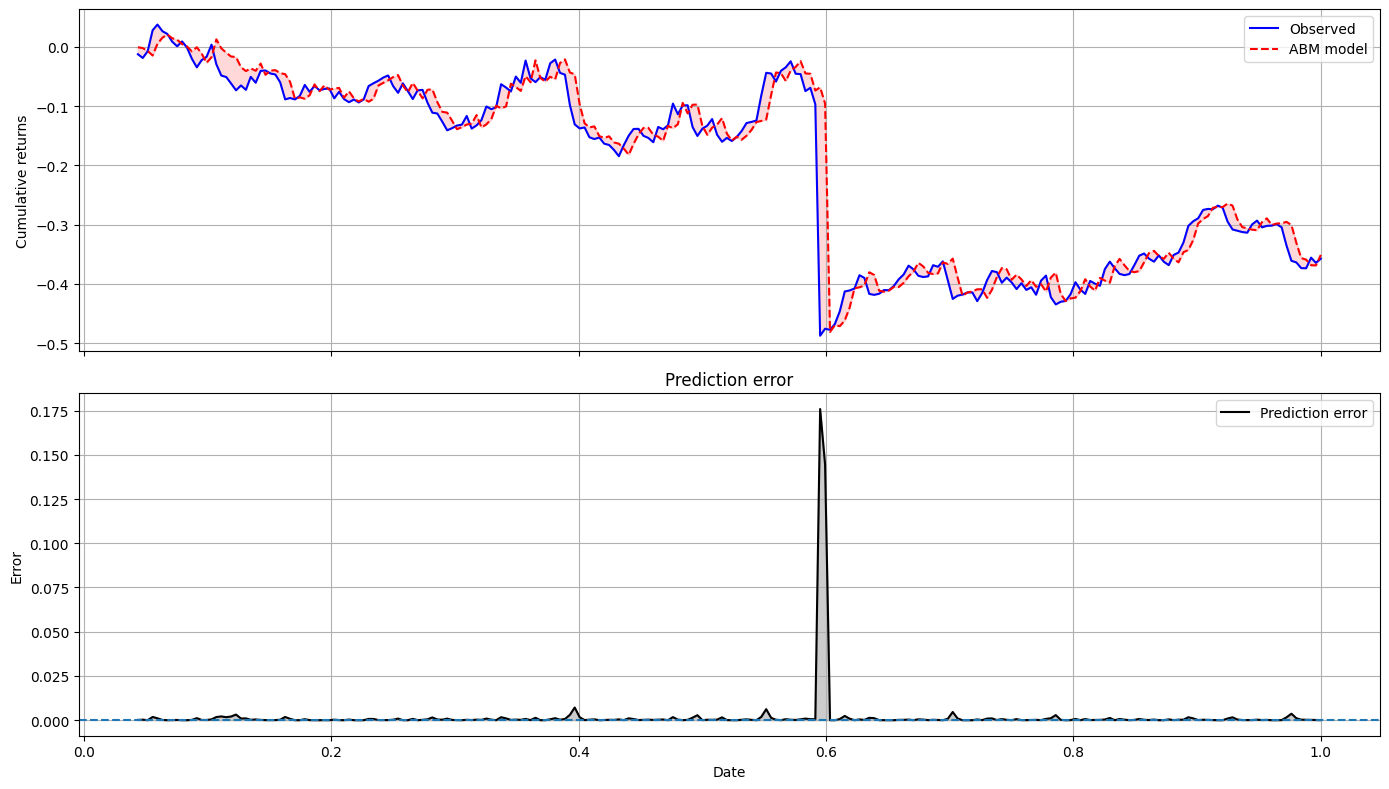

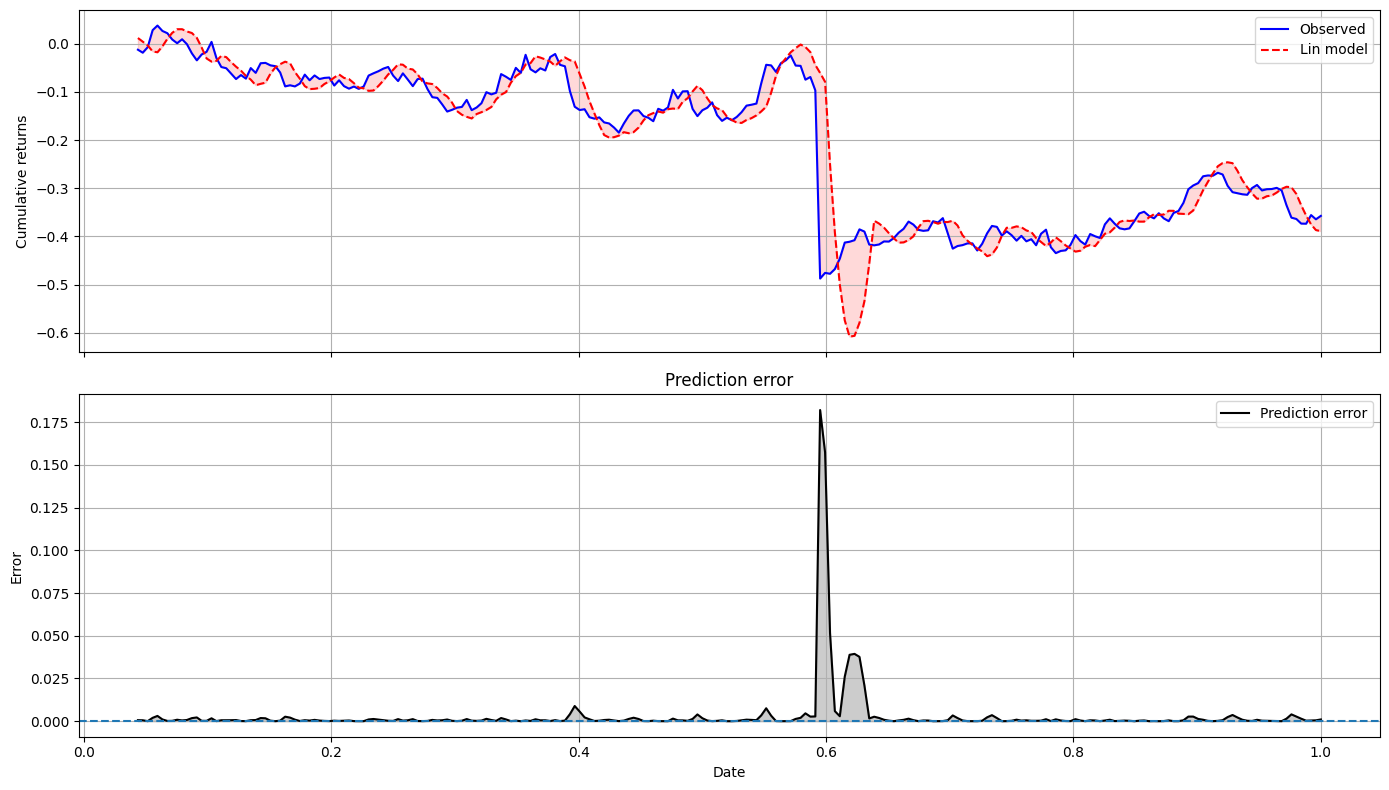

In [17]:
print('========== Bates price process ==========')
aux_series_plot(cumulative_returns_bates,predictions_bates_df)

In [18]:

returns,time_grid = merton_jump_process(
    mu=0.05,
    sigma=0.2,
    jump_intensity=2.0,
    jump_mean=-0.18,
    jump_volatility=0.15,
    maturity=1.0,
    n_steps=252,
    seed=123,
)

returns_merton_ser = pd.Series(returns, index=time_grid.round(4))
cumulative_returns_merton = returns_merton_ser.cumsum()


In [19]:
normalization_window = 1
optimisation_window = 10
env_window = 0

pred_returns_abm = two_state_ising_prediction_gpu(cumulative_returns_merton,normalization_window,optimisation_window,env_window)['series']
pred_returns_lin =  lin_model(cumulative_returns_merton,optimisation_window)

predictions_merton_df = pd.DataFrame({
    'ABM model': pred_returns_abm,
    'Lin model': pred_returns_lin
}
).dropna()


In [20]:
results_merton_df = metrics_performance(original_series=cumulative_returns_merton,predictions_df=predictions_merton_df)
print('========== Merton price process ==========')
print(results_merton_df.to_string())

========== Merton price process ==========
                MAE      RMSE  R2 Score      corr
ABM model  0.017300  0.025589  0.949102  0.975059
Lin model  0.022576  0.033662  0.911925  0.957915


========== Merton price process ==========


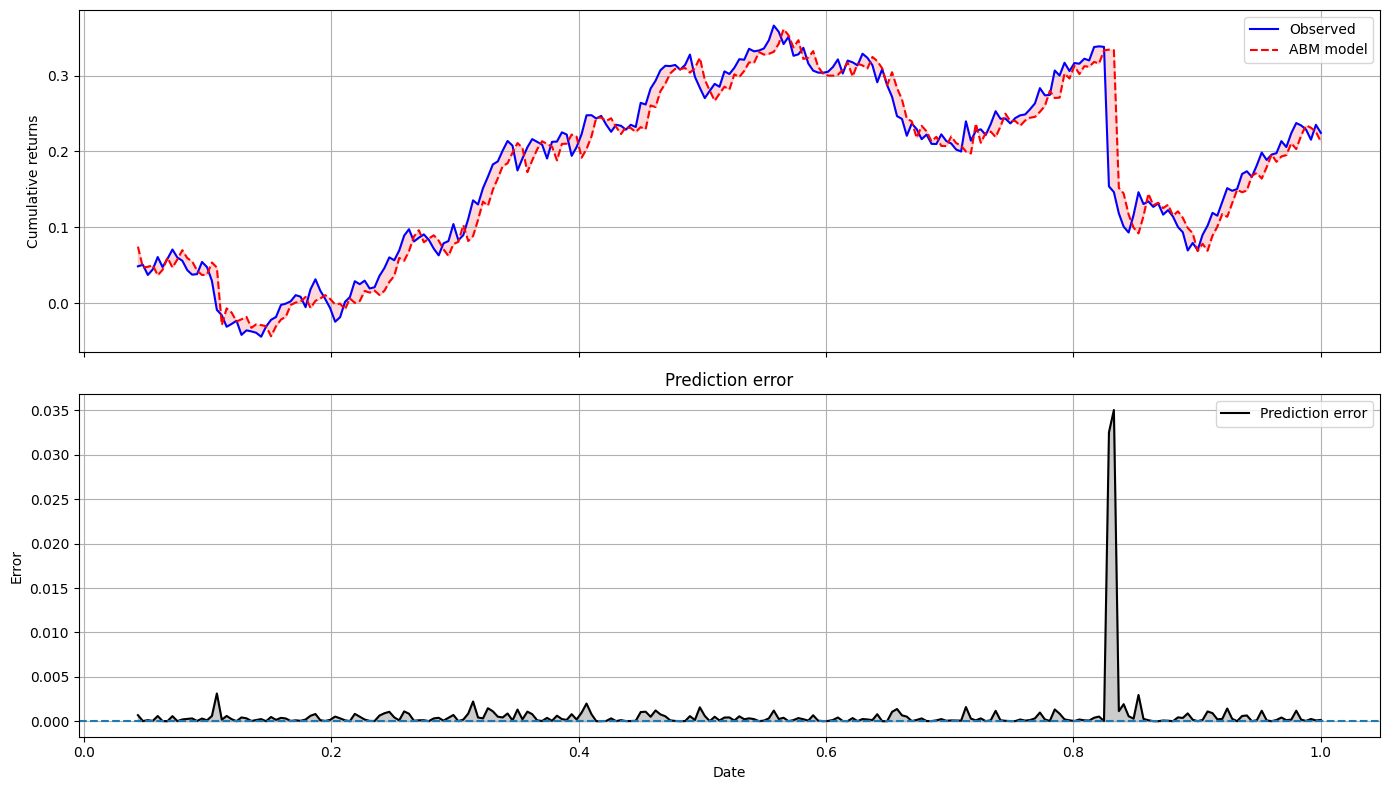

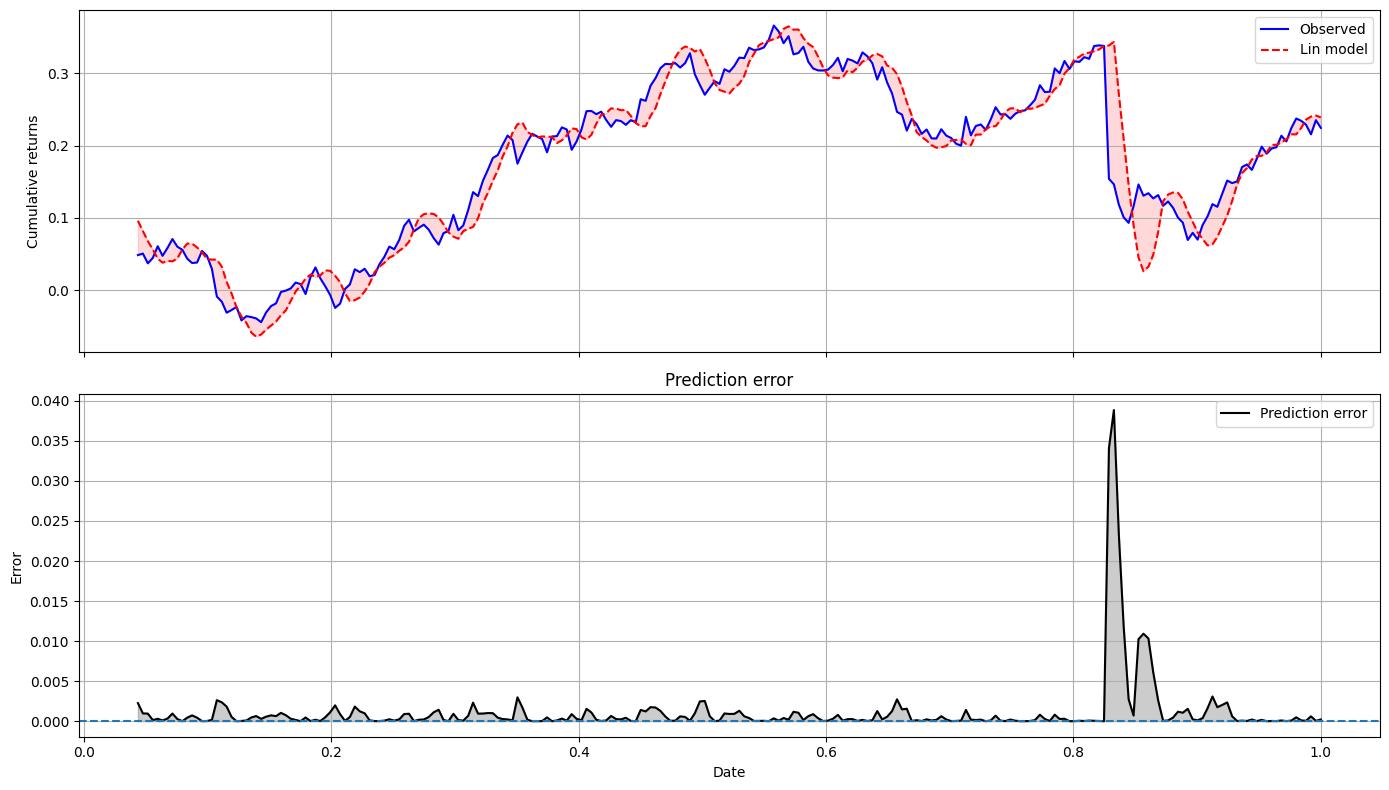

In [21]:
print('========== Merton price process ==========')
aux_series_plot(cumulative_returns_merton,predictions_merton_df)

---

#### Post-Crash Analysis: The Autocorrelation of Prediction Errors

We isolate the prediction errors (residuals) for both the Linear Regression and the Agent-Based Model (ABM):

$$\varepsilon_t = \langle \Delta y \rangle_t - \hat{f}(\dots)$$

We then compute the **Autocorrelation Function (ACF)** of these errors, defined for a lag $\tau$ as:

$$\rho(\tau) = \frac{\text{Cov}(\varepsilon_t, \varepsilon_{t-\tau})}{\text{Var}(\varepsilon_t)}$$

#### Why Autocorrelation of Error Matters:
In a perfectly adapted model, prediction errors should behave like white noise—meaning they are uncorrelated over time ($\rho(\tau) \approx 0$ for all $\tau > 0$). So, if a model fails to adapt quickly to the new post-crash regime, it will consistently overshoot or undershoot. This results in **highly correlated errors** (high $\rho(\tau)$ at low lags) as the model slowly "drags" its historical window forward.

Then, by observing how rapidly the ACF of the residuals decays toward zero after the crash, we can quantitatively measure the adaptability capabilty of the model.

In [22]:


def compute_error_persistence(original_series, prediction_df, max_lag=20, plot=True):
    # Alignment of original serie on prediction_df index
    original_series = original_series.reindex(prediction_df.index)
    original = pd.to_numeric(original_series, errors='coerce').to_numpy(dtype=float)
    
    # Initialize the DataFrame to store the ACF for each model
    error_acf_df = pd.DataFrame(columns=prediction_df.columns)
    
    for x in prediction_df.columns:
        error_acf = []
        predicted = pd.to_numeric(prediction_df[x], errors='coerce').to_numpy(dtype=float)
        
        # Calcul de l'erreur quadratique
        error_values = (predicted - original)**2
        # Convert to a Pandas Series to use the .autocorr() method
        error_series = pd.Series(error_values)
        
        for lag in range(max_lag):
            if lag == 0:
                error_acf.append(1.0)
            else:
                # Correlation between the error at t and the error at t-lag
                corr = error_series.autocorr(lag=lag)
                error_acf.append(corr if not np.isnan(corr) else 0.0)
        
        error_acf_df[x] = error_acf

    # --- Graphics section ---
    if plot:
        plt.figure(figsize=(12, 6))
        x_axis = np.arange(max_lag)
        
        # Offset the bars if there are multiple columns
        width = 0.35 if len(prediction_df.columns) > 1 else 0.5
        multiplier = 0
        
        colors = ['blue', 'red']
        
        for i, model_name in enumerate(error_acf_df.columns):
            offset = width * multiplier
            # Color selecion
            color_to_use = colors[i % len(colors)]
            
            plt.bar(
                x_axis + offset, 
                error_acf_df[model_name], 
                width, 
                label=model_name,
                color=color_to_use,
                alpha=0.8
            )
            multiplier += 1
            

        
        plt.title("Autocorrelation function of the quadratic error")
        plt.xlabel("temporal Lags")
        plt.ylabel("Autocorrélation")
        plt.xticks(x_axis + (width * (len(prediction_df.columns) - 1) / 2), x_axis)
        plt.ylim(-0.2, 1.1)
        plt.legend()
        plt.grid(True)
        plt.show()

    return error_acf_df



================================== Bates process =======================================


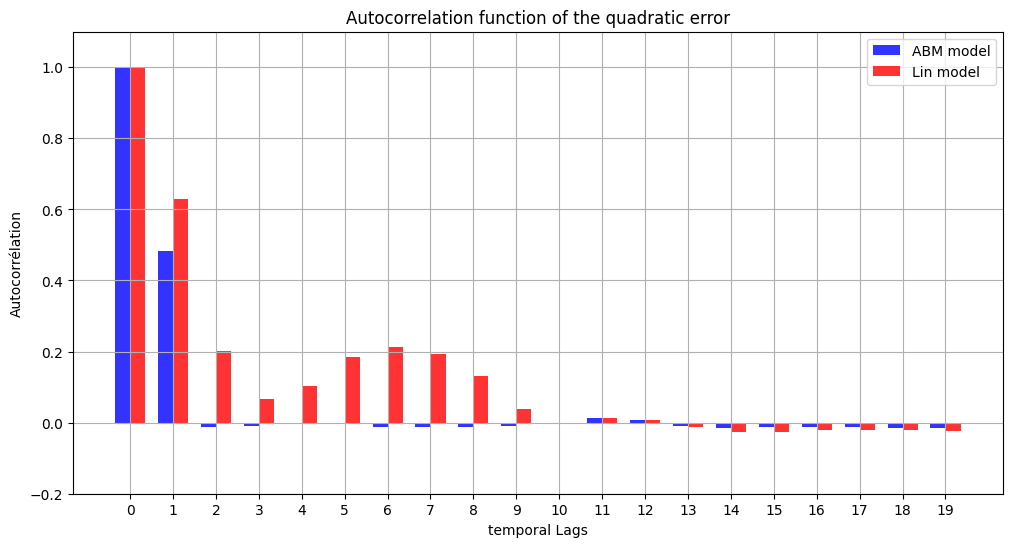

In [23]:
print('================================== Bates process =======================================')
error_persistence_df=compute_error_persistence(cumulative_returns_bates,predictions_bates_df)

================================== Merton process =======================================


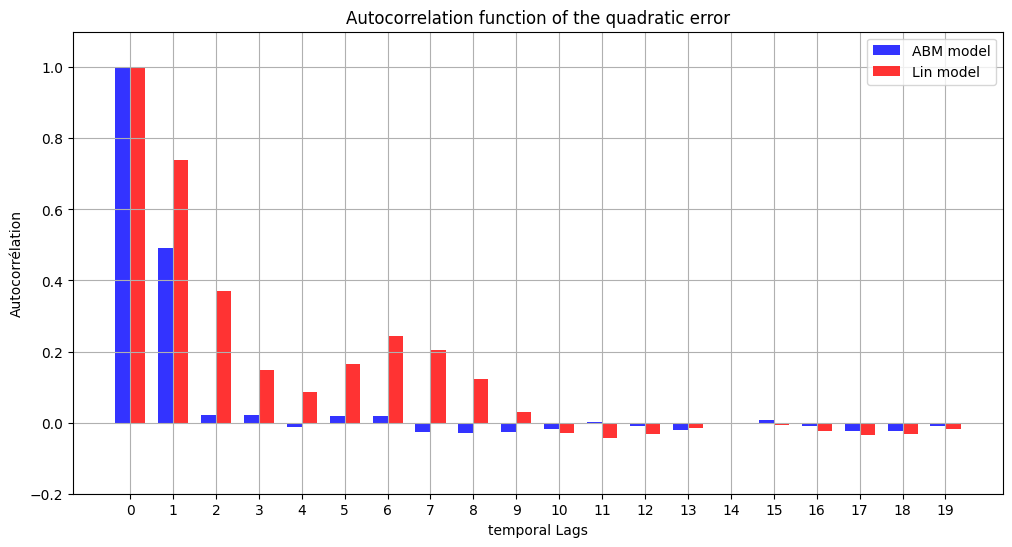

In [24]:
print('================================== Merton process =======================================')
error_persistence_df=compute_error_persistence(cumulative_returns_merton,predictions_merton_df)

### Remarks

By analyzing the autocorrelation function (ACF) of the prediction errors, we can observe that the **Agent-Based Model (ABM)** exhibits a significantly shorter **relaxation time** compared to the **Linear Regression model**. 

* **The Linear Model's "Memory" Drag:** Because the linear model relies on ordinary least squares (OLS) over a fixed historical rolling window, a structural break—such as a sudden jump-induced crash—severely biases the regression parameters. The model continues to project the pre-crash trend forward, resulting in large, systematically correlated errors. The error ACF remains high and decays slowly, lagging behind the market's recovery until the crash data fully exits the rolling window.

* **The ABM's Fast Relaxation:** In contrast, the ABM is better adapting to the new market regime. The gradient-descent algorithm rapidly recalibrates the coupling parameters ($\alpha, \beta$) to absorb the shock. Furthermore, because the model's predictions are filtered through the $\tanh$ activation function, the sudden spike in negative price trend $\langle \Delta y \rangle$ instantly saturates the decision-making process. 

### 3. Influence of Signal Complexity on Predictability

To evaluate and compare the boundaries of our models, we analyze how their predictive performance fluctuates as a function of the local "smoothness" or complexity of the underlying signal. Financial regimes constantly shift between highly structured trends (smooth, persistent periods) and highly erratic, noisy phases.

#### 3.1 Measuring Prediction Performance on Returns

To see at what extent we can exploit that model, the prediction performance of both models is evaluated on **returns** rather than raw cumulative series. 

Let $y_t$ be the original cumulative series at time $t$, and $\hat{y}_{t}$ be the model's one-step-ahead prediction. 

1. **The True Returns ($R_t$):**
   The actual return is calculated as the first difference of the original series:
   
   $$R_t = y_t - y_{t-1}$$

2. **The Predicted (Forecasted) Returns ($\hat{R}_t$):**
   The forecasted return is the difference between our model's one-step prediction for tomorrow and the actual value observed today:
   
   $$\hat{R}_t = \hat{y}_t - y_{t-1}$$

WWe align these two series over the out-of-sample testing period to compute our performance metric, the **Pearson Correlation Coefficient**  between the actual and predicted returns:

---

### 3.2 Dynamic Complexity: Shannon Entropy of the Power Spectral Density (PSD)

While the  Correlation Coefficient provides an average performance metric, we want to map this performance against the changing local smoothness of the market. To achieve this, we smooth the  dynamically by applying a **rolling window average** over the simulated cumulative returns.

For each window, we compute the **Power Spectral Density (PSD)** on the smoothed cumulative returns using a Fast Fourier Transform (FFT). The PSD represents how the signal's energy is distributed across different frequencies:

$$S(f) = |X(f)|^2$$

We then normalize the PSD so that it acts as a probability distribution:

$$P(f_i) = \frac{S(f_i)}{\sum_{j=1}^{M} S(f_j)}$$

where $M$ is the number of discrete frequency bins. The complexity (or lack of smoothness) of the local price path is quantitatively measured using the **Shannon entropy** of this normalized power spectral distribution:

$$H_{\text{PSD}} = -\sum_{i=1}^{M} P(f_i) \ln P(f_i)$$

#### Interpretation of $H_{\text{PSD}}$:

* **Low Entropy ($H_{\text{PSD}} \to 0$):** The signal is highly **smooth, ordered, and structured**. In the frequency domain, the energy is concentrated in a few dominant low-frequency peaks (representing clear, predictable trends).
* **High Entropy ($H_{\text{PSD}} \to H_{\max}$):** The signal is **noisy, chaotic, and resembles white noise**. In the frequency domain, the power spectral density is flat and evenly spread across all frequencies, signifying a lack of underlying structural patterns.

By running our rolling window across the time series, we dynamically map the prediction performance (the local $R^2_{\text{oos}}$ calculated on returns) of both the Linear and the Agent-Based Model against this local entropy. This allows us to empirically determine how increasing market noise limits the predictive boundaries of the non-linear ABM relative to the baseline linear model.


In [25]:
import matplotlib.pyplot as plt
from scipy.signal import welch
def power_spec_entropy(series):
    series = pd.to_numeric(series, errors='coerce').dropna().to_numpy()
    freq, psd = welch(series,nperseg=min(len(series), 256))

    psd_norm = psd / np.sum(psd)
        
    # 3. Calculate Shannon Entropy on the normalized spectrum
    # We avoid log(0) by using np.errstate or masking zero values
    psd_norm_safe = psd_norm[psd_norm > 0]
    shannon_entropy = -np.sum(psd_norm_safe * np.log2(psd_norm_safe))
    
    #Normalize the entropy to fall strictly between 0 (smooth/deterministic) and 1 (white noise)
    max_entropy = np.log2(len(psd_norm))
    spectral_entropy = shannon_entropy / max_entropy
    return spectral_entropy

In [26]:
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score

# 1. On aligne les index directement sur les pas du rolling_window
windows = list(range(0, 50, 5))  # [0, 10, 20, 30, 40]
Corrs = pd.DataFrame(0.0, index=windows,columns=predictions_bates_df.columns)
ps_entropy = pd.DataFrame(0.0, index=windows,columns=predictions_bates_df.columns)

for rolling_window in windows:
    
    if rolling_window == 0:
        original_series = cumulative_returns_bates
    else:
        original_series = cumulative_returns_bates.rolling(rolling_window).mean()


    ### abm model
    predicted_series_abm = two_state_ising_prediction_gpu(
        original_series, 
        normalization_window, 
        optimisation_window, 
        env_window
    )['series']

    forecasted_returns = (predicted_series_abm - original_series.shift()).dropna()
    original_returns = original_series.diff().dropna()
    common_idx = original_returns.index.intersection(forecasted_returns.index)
    
    Corrs.loc[rolling_window,'ABM model'] = original_returns.loc[common_idx].corr(forecasted_returns.loc[common_idx])
  
    ps_entropy.loc[rolling_window,'ABM model'] = power_spec_entropy(original_series) 
    
    ### lin model
    predicted_series_lin = lin_model(
        original_series, 
        optimisation_window
    )

    forecasted_returns = (predicted_series_lin - original_series.shift()).dropna()
    original_returns = original_series.diff().dropna()
    common_idx = original_returns.index.intersection(forecasted_returns.index)
    
    Corrs.loc[rolling_window,'Lin model'] = original_returns.loc[common_idx].corr(forecasted_returns.loc[common_idx])
  
    ps_entropy.loc[rolling_window,'Lin model'] = power_spec_entropy(original_series) 





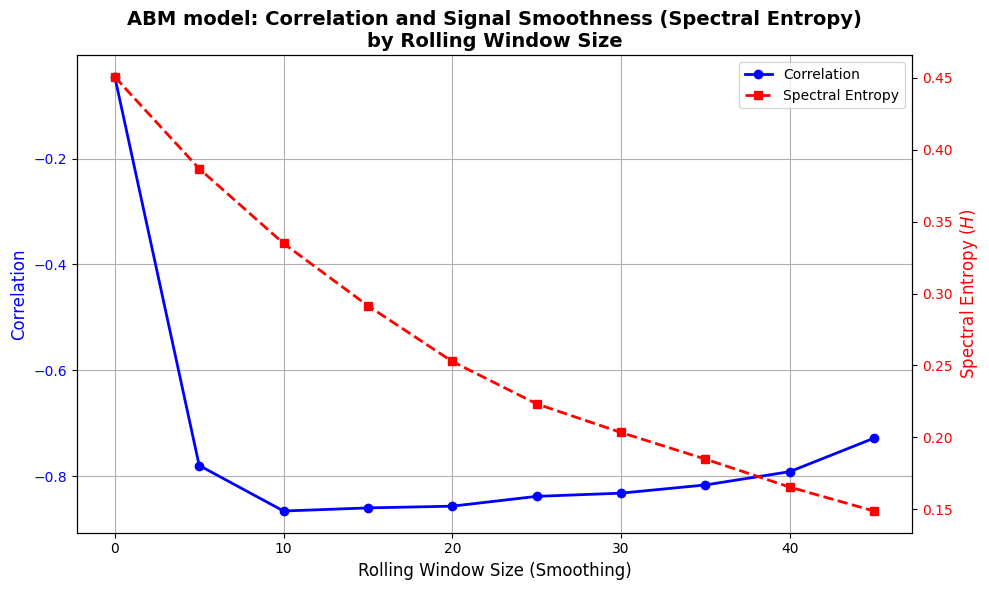

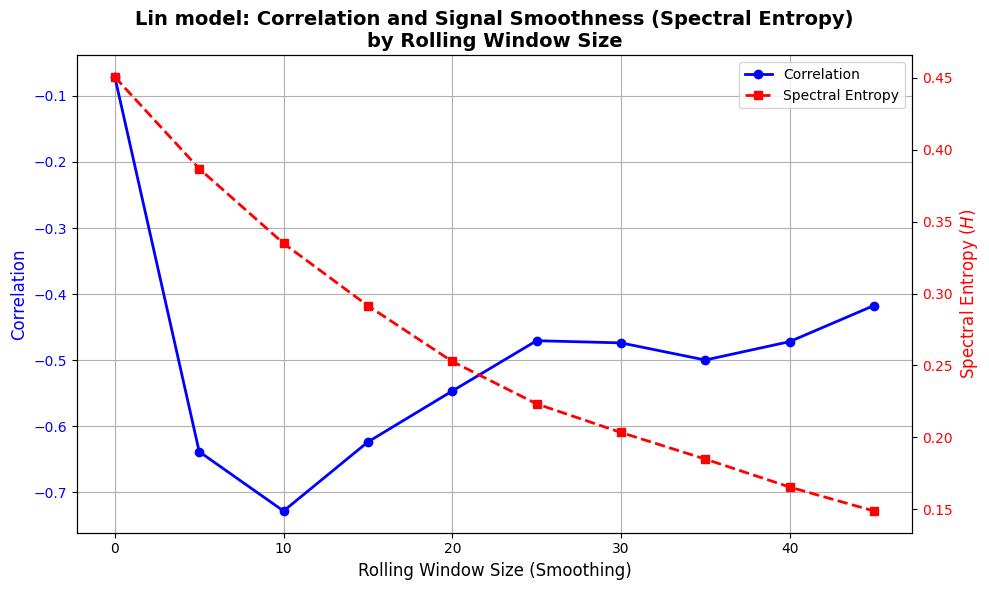

In [27]:
for model in predictions_bates_df.columns:
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Premier axe Y : Score R² (en bleu)
    color = 'blue'
    ax1.set_xlabel('Rolling Window Size (Smoothing)', fontsize=12)
    ax1.set_ylabel('Correlation', color=color, fontsize=12)
    line1 = ax1.plot(windows, Corrs[model], marker='o', color=color, linewidth=2, label='Correlation')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True)

    # Second axe Y partageant le même axe X : Entropie Spectrale (en rouge)
    ax2 = ax1.twinx()  
    color = 'red'
    ax2.set_ylabel('Spectral Entropy ($H$)', color=color, fontsize=12)
    line2 = ax2.plot(windows, ps_entropy[model], marker='s', linestyle='--', color=color, linewidth=2, label='Spectral Entropy')
    ax2.tick_params(axis='y', labelcolor=color)

    # Gestion de la légende unique pour les deux courbes
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper right')

    plt.title(f'{model}: Correlation and Signal Smoothness (Spectral Entropy)\nby Rolling Window Size', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

### Remarks

By analyzing the correlation between the forecasted and the actual returns, one can observe that the **Agent-Based Model (ABM)** acheive much quicker strong correlation **relaxation time** compared to the **Linear Regression model**. Also one have very low correlation for brut cumulative returns, showing that there is no predictive capacity for both models 

* **The Linear Model:** Because the linear model relies on fixed historical rolling window we can see that it achieves maximum correlation when the rolling window correspond to the optimisation window

* **The ABM's Fast  Relaxation:** the ABM correlation in function of the rolling window decay quickly to a high negative correlation (approx -0.9) proving a strong prediction capability for smoothed returns 

### Conclusion

This study investigated the predictive performance and adaptive capabilities of a non-linear Agent-Based Model (ABM) compared to a benchmark Linear Regression model. By analyzing both models through the dual lenses of post-crash recovery and signal complexity, several key insights emerged:

1. **Superior Adaptation to Structural Breaks:** The Linear Regression model suffered from a severe "memory drag", due to its reliance on a fixed historical window. Conversely, the ABM exhibited a significantly shorter relaxation time. Thanks to its rapid parameter recalibration and the non-linear saturation of its $\tanh$ activation function, the ABM instantly aligned with the new post-crash regime, restoring a strong correlation with actual returns almost immediately.

2. **Predictive Boundaries and Signal Complexity:** By mapping correlation ($r_{\text{oos}}$) against the dynamic smoothness of the cumulative series—measured via the Shannon entropy of the Power Spectral Density ($H_{\text{PSD}}$)—we established clear boundaries of predictability. While both models perform well under highly ordered, low-entropy regimes, the  ABM maintains a robust predictive edge over the linear model. However, as the signal approaches maximum entropy (resembling pure white noise), both models naturally converge toward the theoretical limits of predictability.

Ultimately, this work demonstrates that while linear models are computationally efficient, they are fundamentally ill-equipped to handle the non-linear phase transitions and regime shifts characteristic of real-world financial crises. Incorporating agent-based, non-linear frameworks provides a much more resilient and biologically inspired approach to market forecasting, capturing the rapid behavioral shifts of market participants when structural breaks occur. 


### Perspectives


#### 1. Applications in Finance
Due to the low signal-to-noise ratio in finance, the model cannot be directly applied to directional price prediction. However, it is highly valuable for:
* **Exotic Options:** Specifically **Geometric Asian Options**, since their payoff depends on the average of log-prices, which naturally filters out high-frequency noise (see the pca project).
* **Alternative Features:** Modeling non-directional market dynamics such as trading volume or volatility.

#### 2. Future Enhancements
A key improvement is introducing a **neutral attitude** ($x_i = 0$) for traders:
* **Faster Relaxation:** Allowing agents to do nothing under high uncertainty should significantly reduce the model's post-crash relaxation time.
* **Cont-Bouchaud Comparison:** While the Cont-Bouchaud model already includes static inactivity, comparing its approach to the one from **Kaizoji** is a valuable path to investigate.